# 14_kNN

# k-Nearest Neighbors

앞 강의에서는 Logistic Regression을 이용하여 Binary Classification을 수행하였다.

Logistic Regression은 Data로부터 Weight와 Bias를 Learning하고,

$$
P(y=1|X)
$$

를 계산하여 Class를 결정하였다.

이번에는 전혀 다른 방법으로 Classification을 수행한다.

새로운 Data와 가장 가까운 기존 Data들을 찾아 그들의 Class를 이용하는 방법이다.

이를 k-Nearest Neighbors, 줄여서 k-NN이라고 한다.

## Classification (분류)

Given $\{ (x_i, y_i) \}_i=1, 2, \cdots, N$, where $x_i$ belongs to the class represented by $y_i$, find the lable for a new data $x$.  

class = label

지도학습(Supervised Learning)

> kNN = k-Nearest Neighborhood

## Clustring (군집화)

Given $\{ (x_i) \}_i=1, 2, \cdots, N$, find the cluster that represnets $\{ (x_i) \}_i=1, 2, \cdots, N$.

비지도학습(Unsupervised Learning)

> kMean

In [ ]:
# k-NN for Classification

### 닥스훈트 데이터
d = [[75, 24], [77, 29], [83, 19], [81, 32], [73, 21], \
      [99, 22], [72, 19], [83, 34]]
### 사모예드 데이터
s = [[76, 55], [78, 58], [82, 53], [88, 54], [76, 61], \
     [83, 52], [81, 57], [89, 64]]
### 말티즈 데이터
m = [[35, 23], [39, 26], [38, 19], [41, 30], [30, 21], \
     [57, 24], [41, 28], [35, 20]]

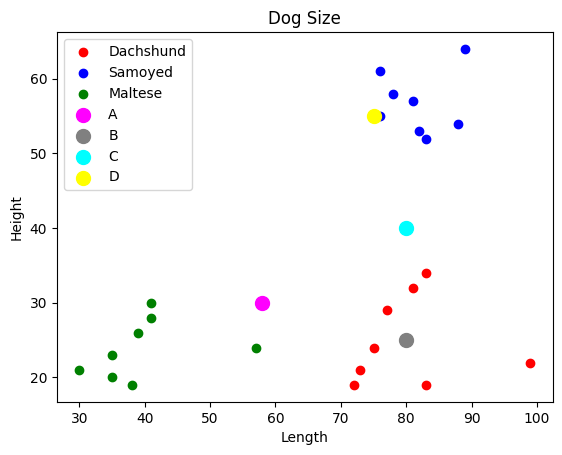

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

d_arr = np.array(d)
s_arr = np.array(s)
m_arr = np.array(m)

plt.scatter(d_arr[:, 0], d_arr[:, 1], c='red', label='Dachshund')
plt.scatter(s_arr[:, 0], s_arr[:, 1], c='blue', label='Samoyed')
plt.scatter(m_arr[:, 0], m_arr[:, 1], c='green', label='Maltese')

A = [[58, 30]]
B = [[80, 25]]
C = [[80, 40]]
D = [[75, 55]]

plt.scatter(A[0][0], A[0][1], s=100, c='magenta', label='A')
plt.scatter(B[0][0], B[0][1], s=100, c='gray', label='B')
plt.scatter(C[0][0], C[0][1], s=100, c='cyan', label='C')
plt.scatter(D[0][0], D[0][1], s=100, c='yellow', label='D')

plt.xlabel('Length')
plt.ylabel('Height')
plt.title('Dog Size')
plt.legend(loc='upper left')
plt.show()

In [ ]:
dogs = d + s + m    # term by term 덧셈이 아니라 접합(concatenation)
print(dogs)

[[75, 24], [77, 29], [83, 19], [81, 32], [73, 21], [99, 22], [72, 19], [83, 34], [76, 55], [78, 58], [82, 53], [88, 54], [76, 61], [83, 52], [81, 57], [89, 64], [35, 23], [39, 26], [38, 19], [41, 30], [30, 21], [57, 24], [41, 28], [35, 20]]


In [ ]:
labels = [0] * len(d) + [1] * len(s) + [2] * len(m)
print(labels)

[0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2]


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

dog_classes = {0: 'Dachshund', 1:'Samoyed', 2:'Maltese'}
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(dogs, labels)

KNeighborsClassifier(n_neighbors=1)

In [ ]:
print('A', dog_classes[knn.predict(A)[0]])
print('B', dog_classes[knn.predict(B)[0]])
print('C', dog_classes[knn.predict(C)[0]])
print('D', dog_classes[knn.predict(D)[0]])

A Maltese
B Dachshund
C Dachshund
D Samoyed


In [ ]:
pred = knn.predict(dogs)
print(pred)

[0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2]


In [ ]:
from sklearn.metrics import confusion_matrix    # 가로 - predicted label, 세로 - true label

cm = confusion_matrix(labels, pred)
print(cm)

[[8 0 0]
 [0 8 0]
 [0 0 8]]


## Iris Dataset

Iris Dataset은 Machine Learning에서 Classification을 설명할 때 널리 사용되는 간단한 Dataset이다.

150개의 Iris Flower에 대해 다음 4개의 Features가 측정되어 있다.

- Sepal Length: 꽃받침 길이
- Sepal Width: 꽃받침 너비
- Petal Length: 꽃잎 길이
- Petal Width: 꽃잎 너비

각 Flower는 다음 세 Class 중 하나에 속한다.

- Setosa
- Versicolor
- Virginica

따라서 Iris Dataset은

$$
4\text{ Features} \rightarrow 3\text{ Classes}
$$

를 예측하는 Multi-class Classification Problem이다.

이번 강의에서는 새로운 Iris Flower의 4개 Feature가 주어졌을 때 가까운 Training Data를 이용하여 Flower의 Class를 예측한다.

## Practice

Iris Dataset을 이용하여 k-NN Classification을 수행한다.

다음 조건을 사용한다.

- Input Features: Sepal Length, Sepal Width, Petal Length, Petal Width
- Output: Iris Class
- `test_size=0.2`
- `random_state=42`

다음 과정을 수행한다.

- $k=3$인 k-NN Model을 만든다.
- Test Data의 Accuracy를 계산한다.
- $k=1,3,5,7,9$에 대해 Test Accuracy를 비교한다.
- 가장 높은 Test Accuracy를 얻은 $k$를 확인한다.
- Test Data의 첫 번째 Sample에 대해 Actual Class와 Predicted Class를 비교한다.

In [3]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Iris Dataset
iris = load_iris()

X = iris.data
y = iris.target

# Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# k = 3
model = KNeighborsClassifier(
    n_neighbors=3
)

model.fit(
    X_train,
    y_train
)

y_pred = model.predict(
    X_test
)

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred)
)

# Different k values
for k in [1, 3, 5, 7, 9]:

    model = KNeighborsClassifier(
        n_neighbors=k
    )

    model.fit(
        X_train,
        y_train
    )

    y_pred = model.predict(
        X_test
    )

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    print(
        f"k={k}, Accuracy={accuracy:.3f}"
    )

# 첫 번째 Test Sample
model = KNeighborsClassifier(
    n_neighbors=3
)

model.fit(
    X_train,
    y_train
)

prediction = model.predict(
    X_test[[0]]
)

print(
    "Actual Class:",
    iris.target_names[y_test[0]]
)

print(
    "Predicted Class:",
    iris.target_names[prediction[0]]
)

Accuracy: 1.0
k=1, Accuracy=1.000
k=3, Accuracy=1.000
k=5, Accuracy=1.000
k=7, Accuracy=0.967
k=9, Accuracy=1.000
Actual Class: versicolor
Predicted Class: versicolor


## Practice

Iris Dataset의 4개 Features 중 다음 두 Features만 사용하여 k-NN Classification을 수행한다.

- Petal Length
- Petal Width

전체 150개 Data를 Random하게 섞은 후

- 100 Samples: Training Data
- 50 Samples: Test Data

로 사용한다.

$k=5$인 k-NN Model을 Training하고 Test Data의 Classification 결과를 분석한다.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.utils import shuffle
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

# Iris Dataset
iris = load_iris()

# 3번째, 4번째 Feature만 사용
# Petal Length, Petal Width
X = iris.data[:, 2:4]
y = iris.target

# Data를 Random하게 섞음
X, y = shuffle(
    X,
    y,
    random_state=42
)

# 처음 100개: Training
X_train = X[:100]
y_train = y[:100]

# 나머지 50개: Test
X_test = X[100:]
y_test = y[100:]

print("Training Data:", X_train.shape)
print("Test Data:", X_test.shape)

Training Data: (100, 2)
Test Data: (50, 2)


## Train k-NN

Training Data를 이용하여 $k=5$인 k-NN Model을 만든다.

Test Data에 대해 Class를 Prediction하고 Accuracy를 계산한다.

In [5]:
# k-NN Model
model = KNeighborsClassifier(
    n_neighbors=5
)

# Training
model.fit(
    X_train,
    y_train
)

# Prediction
y_pred = model.predict(
    X_test
)

# Accuracy
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Correct:", np.sum(y_test == y_pred))
print("Total:", len(y_test))
print("Accuracy:", accuracy)

Correct: 49
Total: 50
Accuracy: 0.98


## Visualize the Test Result

Petal Length와 Petal Width 두 Features만 사용했기 때문에 Classification 결과를 2차원 공간에서 직접 확인할 수 있다.

먼저 실제 Class를 그려 보자.

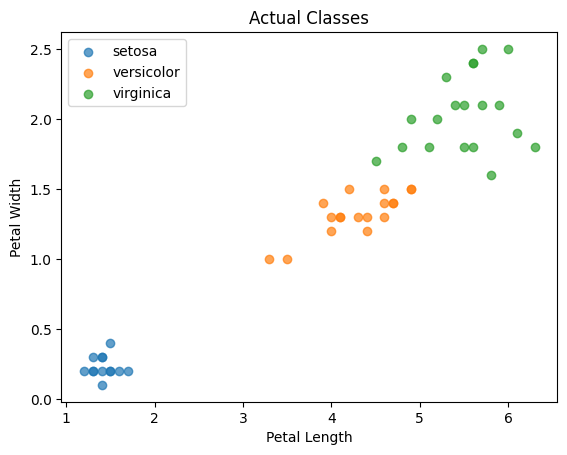

In [6]:
# Actual Classes
for class_id in [0, 1, 2]:

    points = X_test[
        y_test == class_id
    ]

    plt.scatter(
        points[:, 0],
        points[:, 1],
        label=iris.target_names[class_id],
        alpha=0.7
    )

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Actual Classes")
plt.legend()

plt.show()

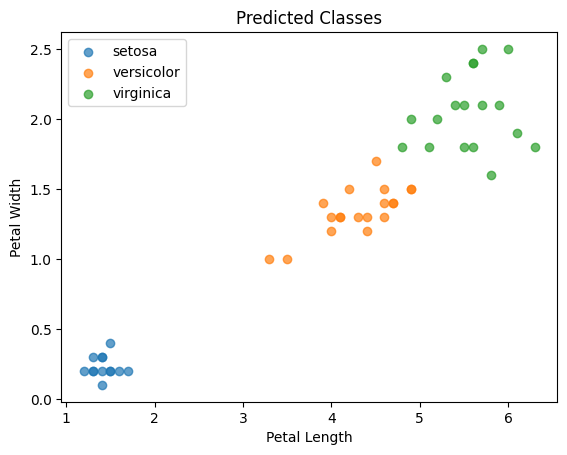

In [8]:
# Predicted Classes
for class_id in [0, 1, 2]:

    points = X_test[
        y_pred == class_id
    ]

    plt.scatter(
        points[:, 0],
        points[:, 1],
        label=iris.target_names[class_id],
        alpha=0.7
    )

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Predicted Classes")
plt.legend()

plt.show()

## Where Did the Model Make Mistakes?

Test Data 중 실제 Class와 Predicted Class가 다른 Sample을 찾아보자.

Correct Prediction과 Wrong Prediction을 구분하여 표시하면 k-NN이 어떤 영역에서 Classification을 어려워하는지 확인할 수 있다.

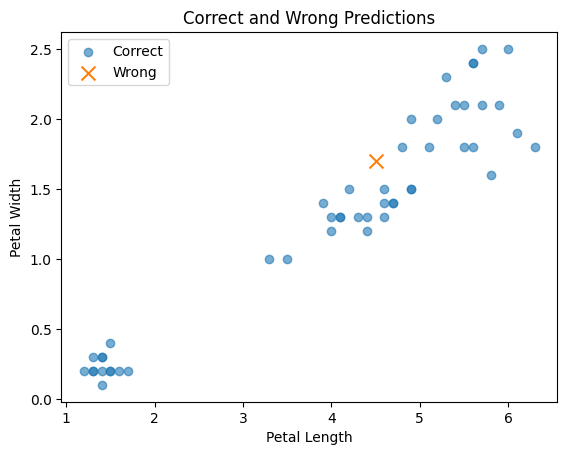

Wrong Predictions: 1


In [9]:
# Correct / Wrong Prediction
correct = y_test == y_pred
wrong = y_test != y_pred

# Correct
plt.scatter(
    X_test[correct, 0],
    X_test[correct, 1],
    label="Correct",
    alpha=0.6
)

# Wrong
plt.scatter(
    X_test[wrong, 0],
    X_test[wrong, 1],
    marker="x",
    s=100,
    label="Wrong"
)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Correct and Wrong Predictions")
plt.legend()

plt.show()

print(
    "Wrong Predictions:",
    np.sum(wrong)
)

## Confusion Matrix

Accuracy는 전체 Test Data 중 몇 개를 올바르게 Classification했는지를 보여준다.

그러나 어떤 Class를 어떤 Class로 잘못 분류했는지는 알 수 없다.

Confusion Matrix를 이용하면 Actual Class와 Predicted Class의 관계를 확인할 수 있다.

Row:

Actual Class

Column:

Predicted Class

In [10]:
# Confusion Matrix
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[13  0  0]
 [ 0 18  0]
 [ 0  1 18]]


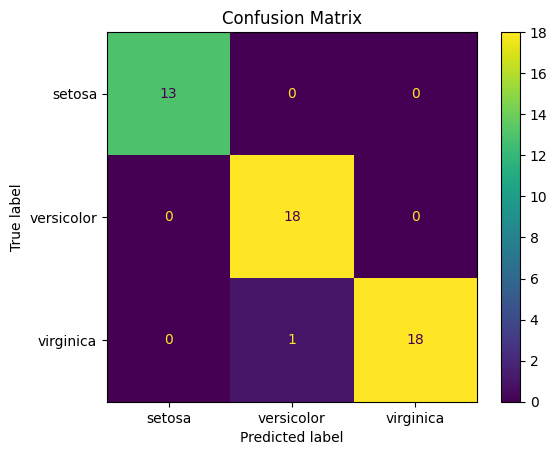

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
).plot()

plt.title("Confusion Matrix")
plt.show()

## Interpreting the Result

Confusion Matrix의 Diagonal 값은 올바르게 Classification된 Sample의 수를 나타낸다.

Diagonal이 아닌 위치의 값은 잘못 Classification된 Sample의 수를 나타낸다.

따라서 Accuracy와 Confusion Matrix를 함께 사용하면 Model의 Classification 결과를 더 자세히 분석할 수 있다.

이번 Practice에서는 4개의 Iris Features 중 Petal Length와 Petal Width 두 개만 사용하였다.

그럼에도 두 Features만으로 세 Iris Classes를 상당 부분 구분할 수 있는지 확인할 수 있다.

## Homework - Problem 14

Iris Dataset을 이용하여 k-NN Classification을 수행한다.

다음 조건을 사용한다.

- 처음 두 Features만 사용한다.
  - Sepal Length
  - Sepal Width
- `random_state=42`를 사용하여 전체 Data의 순서를 Random하게 섞는다.
- 처음 100 Samples를 Training Data로 사용한다.
- 나머지 50 Samples를 Test Data로 사용한다.
- $k=5$인 k-NN Model을 사용한다.

다음 질문에 답하시오.

- Training Data의 크기를 적으시오.
- Test Data의 크기를 적으시오.
- Test Data 50개 중 올바르게 Classification한 Sample의 수를 적으시오.
- Test Accuracy를 소수점 셋째 자리까지 적으시오.
- $k=1,3,5,7,9$ 중 가장 높은 Test Accuracy를 얻은 $k$를 적으시오.

답만 제출하시오.